# **Notebook 04: Hierarchical Adaptive Retrieval Policy**

**Description:** This notebook fits a three-stage routing policy on paired, available Natural Questions training data, selects models and thresholds using Natural Questions validation only, and serializes an auditable policy bundle without inspecting TechQA outcomes.

**Main Questions This Notebook Should Answer:**

- Which actions are the cheapest successful choices on the paired source-domain cohort?
- Can each routing stage be trained without target-domain or future-stage feature leakage?
- Which validation-only thresholds optimize the declared utility and cost objective?
- Which examples were excluded because an API response was unavailable?

---

# **Part 1: Setup and Artifact Contract**

### **Environment Setup**


In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / 'src/adaptive_rag').is_dir() and (p / 'config').is_dir())
sys.path.insert(0, str(REPO_ROOT / 'src'))
ROOT = Path(os.environ.get('ADAPTIVE_RAG_PROJECT_ROOT', REPO_ROOT)).resolve()
from adaptive_rag.luna_v2.common import load_config, load_table, read_json, save_table
cfg = load_config(ROOT)

### **Figure Export Helper**


In [2]:
FIGURES = cfg['paths']['artifacts'] / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 24)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})
print('Run:', cfg['version'], '| model:', cfg['generation']['model'])
print('Outputs:', cfg['paths']['artifacts'].relative_to(ROOT))

Run: luna-v2 | model: gpt-5.6-luna
Outputs: artifacts\luna_v2


### **Load Paired Generation and Retrieval Artifacts**

Report unavailable responses, then keep only examples with all three conditions for matched policy labels.

In [3]:
from adaptive_rag.luna_v2.evaluation import paired_complete_cases, replay_actions, metric_summary
from adaptive_rag.luna_v2.policy import train_policy, predict_actions
cohort = load_table(cfg, 'cohort', processed=True)
rankings = load_table(cfg, 'rankings')
evaluated_all = load_table(cfg, 'evaluated_generations')
evaluated, exclusions = paired_complete_cases(evaluated_all)
display(exclusions)
print('Paired analysis examples:', evaluated.example_id.nunique())
display(cohort.groupby(['domain', 'split']).size().rename('examples').reset_index())

,example_id,domain,split,unavailable_conditions,unavailable_statuses
0,techqa_DEV_Q037,techqa,techqa_test,hybrid_rrf_reranked,failed
1,techqa_DEV_Q104,techqa,techqa_test,direct,failed
2,techqa_DEV_Q114,techqa,techqa_test,"direct,hybrid_rrf,hybrid_rrf_reranked",failed
3,techqa_DEV_Q137,techqa,techqa_test,direct,failed
4,techqa_DEV_Q157,techqa,techqa_test,direct,failed
5,techqa_DEV_Q234,techqa,techqa_test,direct,failed
6,techqa_DEV_Q270,techqa,techqa_test,"hybrid_rrf,hybrid_rrf_reranked",failed
7,techqa_TRAIN_Q111,techqa,techqa_test,direct,failed
8,techqa_TRAIN_Q192,techqa,techqa_test,direct,failed
9,techqa_TRAIN_Q200,techqa,techqa_test,direct,failed


Paired analysis examples: 1263


,domain,split,examples
0,natural_questions,nq_test,74
1,natural_questions,train,221
2,natural_questions,validation,74
3,techqa,techqa_test,908


---

# **Part 2: Oracle Labels, Splits, and Feature Contract**



### **Train Source-Only Stage Models and Select Thresholds**

The best-observed ABSTAIN action on an answerable all-fail example is an action-selection proxy, not evidence of intrinsic unanswerability. Fit the text vocabulary, centroid, neighbours, and models on NQ training; use NQ validation for selection.

In [4]:
bundle, diagnostics, threshold_search = train_policy(cfg, cohort, rankings, evaluated)
display(diagnostics)
display(threshold_search.head(10).round(5))
print('Frozen thresholds:', bundle['thresholds'])

,stage,training_examples,positive_examples,negative_examples,validation_examples,selected_model,validation_brier,candidate_brier,rare_class_fallback
0,continue_after_query,221,147,74,74,constant,0.228176,"{'constant': 0.22817615018839402, 'logistic': ...",False
1,continue_after_hybrid,147,117,30,48,constant,0.189608,"{'constant': 0.1896084964598084, 'logistic': 0...",False
2,escalate_or_abstain,117,11,106,36,tree,0.021581,"{'constant': 0.031393819855358315, 'logistic':...",False


,threshold_1,threshold_2,threshold_3,validation_objective
20,0.00,1.01,0.00,0.35033
21,0.00,1.01,0.25,0.35033
22,0.00,1.01,0.50,0.35033
23,0.00,1.01,0.75,0.35033
24,0.00,1.01,1.01,0.35033
45,0.25,1.01,0.00,0.35033
46,0.25,1.01,0.25,0.35033
47,0.25,1.01,0.50,0.35033
48,0.25,1.01,0.75,0.35033
49,0.25,1.01,1.01,0.35033


Frozen thresholds: [0.0, 1.01, 0.0]


---

# **Part 3: Validation Strategy Comparison**

### **Frozen Validation Replay**

Report answer accuracy, task success, coverage, utility, and actions under the selected thresholds.

In [5]:
validation = cohort[cohort.split.eq('validation')]
validation_actions = predict_actions(bundle, validation, rankings)
validation_replay = replay_actions(cfg, evaluated, rankings, validation_actions, system='adaptive')
display(metric_summary(validation_replay).round(4))
display(validation_replay.action.value_counts().rename('validation_actions').to_frame())

,domain,system,stratum,examples,answerable_examples,answer_accuracy,task_success,coverage,selective_answer_accuracy,unnecessary_abstention_rate,mean_utility,mean_estimated_batch_usd,mean_retrieval_ms
0,natural_questions,adaptive,all,74,74,0.4459,0.4459,0.7432,0.6,0.2568,0.3716,0.0002,105.02
1,natural_questions,adaptive,answerable,74,74,0.4459,0.4459,0.7432,0.6,0.2568,0.3716,0.0002,105.02


,validation_actions
action,
RETRIEVE,74


### **Stage Support Plot**

Make rare or single-class routing stages visible before interpreting the policy.

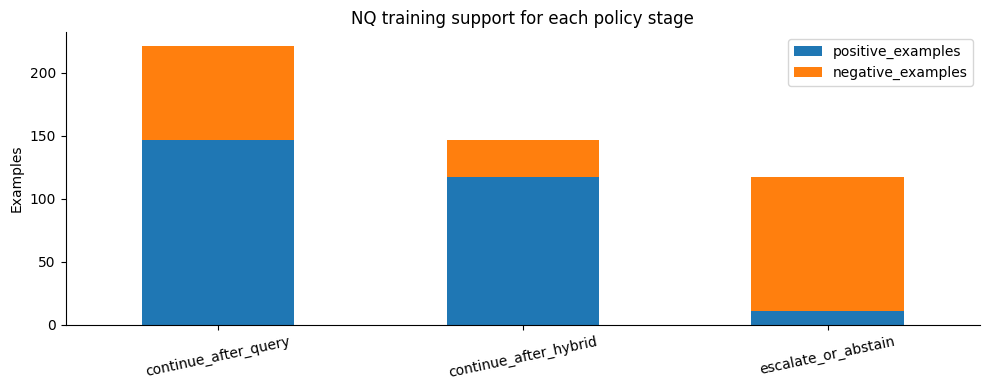

In [6]:
fig, ax = plt.subplots()
diagnostics.set_index('stage')[['positive_examples', 'negative_examples']].plot.bar(stacked=True, ax=ax)
ax.set(title='NQ training support for each policy stage', xlabel='', ylabel='Examples')
ax.tick_params(axis='x', rotation=12)
fig.tight_layout()
fig.savefig(FIGURES / '04_stage_support.png', dpi=160)
plt.show()

### **Reliability-Bin Diagnostic**

Inspect small validation bins without claiming cross-domain probability calibration.

In [7]:
probability_bins = load_table(cfg, 'validation_probability_bins')
display(probability_bins.round(3))
print('These small validation reliability bins are diagnostics, not a cross-domain calibration claim.')

,stage,bin_lower,bin_upper,examples,mean_predicted_probability,observed_positive_rate
0,continue_after_query,0.6,0.8,74,0.665,0.649
1,continue_after_hybrid,0.6,0.8,48,0.796,0.750
2,escalate_or_abstain,0.0,0.2,33,0.009,0.000
3,escalate_or_abstain,0.2,0.4,3,0.278,0.333


These small validation reliability bins are diagnostics, not a cross-domain calibration claim.


### **Validation Routing Interpretation**

The first two routing stages selected constant-probability models with validation Brier scores of 0.228 and 0.190. The final stage selected a shallow tree with Brier 0.0216, although only 11 of its 117 training examples supported escalation. Thresholds [0.00, 1.01, 0.00] routed all 74 validation examples to Hybrid RRF, producing 44.6% task success, 74.3% coverage, and 60.0% selective answer accuracy.

---

# **Part 4: Frozen Policy Manifest**


### **Frozen Manifest Verification**

The bundle contains preprocessing, source reference vectors, stage models, thresholds, split IDs, and provenance hashes. Notebook 05 rejects mismatched artifacts. Verify the saved policy signature and display the training support, thresholds, and stage feature contract.

In [8]:
manifest = read_json(cfg['paths']['artifacts'] / 'policy_manifest.json')
assert manifest['signature'] == bundle['signature']
display(pd.Series({
    'training_examples': manifest['training_examples'],
    'validation_examples': manifest['validation_examples'],
    'thresholds': manifest['thresholds'],
    'policy_signature': manifest['signature'],
}, name='frozen_policy'))
display(manifest['features'])

training_examples                                                    221
validation_examples                                                   74
thresholds                                              [0.0, 1.01, 0.0]
policy_signature       9b1af82479bcdc371a06911b5b6f44f250cbc1b6285ee1...
Name: frozen_policy, dtype: object

{'continue_after_query': ['question_char_length',
  'question_token_length',
  'query_lexical_diversity',
  'punctuation_density',
  'code_symbol_density',
  'numeric_token_density',
  'technical_term_density',
  'nq_centroid_similarity',
  'nearest_train_similarity'],
 'continue_after_hybrid': ['question_char_length',
  'question_token_length',
  'query_lexical_diversity',
  'punctuation_density',
  'code_symbol_density',
  'numeric_token_density',
  'technical_term_density',
  'nq_centroid_similarity',
  'nearest_train_similarity',
  'hybrid_top1',
  'hybrid_margin',
  'hybrid_mean',
  'hybrid_std',
  'hybrid_entropy'],
 'escalate_or_abstain': ['question_char_length',
  'question_token_length',
  'query_lexical_diversity',
  'punctuation_density',
  'code_symbol_density',
  'numeric_token_density',
  'technical_term_density',
  'nq_centroid_similarity',
  'nearest_train_similarity',
  'hybrid_top1',
  'hybrid_margin',
  'hybrid_mean',
  'hybrid_std',
  'hybrid_entropy']}

---

# **Part 5: Interpretation and Handoff**

### **Held-Out Handoff Check**

Confirm that the paired NQ-test and TechQA examples do not overlap policy development IDs.

In [9]:
development_ids = set(bundle['train_ids']) | set(bundle['validation_ids'])
heldout = cohort[
    cohort.split.isin(['nq_test', 'techqa_test']) & cohort.example_id.isin(evaluated.example_id)
]
assert development_ids.isdisjoint(set(heldout.example_id))
display(heldout.groupby(['domain', 'split']).size().rename('paired_examples').reset_index())
print('Ready for notebook 05:', len(heldout), 'paired held-out examples with no development overlap')

,domain,split,paired_examples
0,natural_questions,nq_test,74
1,techqa,techqa_test,894


Ready for notebook 05: 968 paired held-out examples with no development overlap


### **Frozen Policy and Handoff Interpretation**

The source-trained policy did not learn reliable query-dependent routing. Constant predictors beating logistic and tree candidates at the first two stages means the available features did not improve those validation decisions beyond their base rates. The final tree has sparse escalation support and is never reached under the selected second threshold.

The frozen policy therefore represents a validation-selected Hybrid RRF baseline rather than evidence of successful adaptation. Notebook 05 must test that outcome unchanged; retuning after viewing NQ-test or TechQA results would invalidate the held-out evaluation.

---

# **Part 6: Conclusion**

This notebook trained on 221 NQ examples and selected models and thresholds on 74 NQ validation examples. Constant models won the first two stages, a shallow tree won the sparse final stage, and the selected thresholds routed every validation query to Hybrid RRF. Validation answer accuracy and task success were 44.6%, with 74.3% coverage and 60.0% selective accuracy. This is a valid frozen result, but it does not show successful dynamic routing. 

---